In [24]:
import pandas as pd
import numpy as np

# 1. Carica il dataset usando il percorso corretto
df = pd.read_csv('/content/sample_data/pre-owned cars.csv')

# 2. Mostra le prime 5 righe per verificare l'importazione
display(df.head())

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [25]:
# 1. Controlla il numero di righe, colonne e i tipi di dato
df.info()

# 2. Controlla quanti valori mancanti (nulli) ci sono per ogni colonna
print("\n--- VALORI MANCANTI ---")
print(df.isnull().sum())

# 3. Controlla se ci sono righe completamente duplicate
print("\n--- DUPLICATI ---")
print(f"Numero di righe duplicate: {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

In [26]:
# 1. Eliminiamo la colonna 'reg_year' perché ha troppi valori vuoti
df_clean = df.drop(columns=['reg_year'])

# 2. Imputiamo i valori mancanti di 'engine_capacity(CC)' usando la mediana della stessa marca
df_clean['engine_capacity(CC)'] = df_clean.groupby('brand')['engine_capacity(CC)'].transform(
    lambda x: x.fillna(x.median())
)

# 3. Eliminiamo le pochissime righe rimaste che hanno ancora dati vuoti
df_clean = df_clean.dropna()

# 4. Convertiamo 'make_year' e 'engine_capacity(CC)' in interi per pulizia visiva
df_clean['make_year'] = df_clean['make_year'].astype(int)
df_clean['engine_capacity(CC)'] = df_clean['engine_capacity(CC)'].astype(int)

# 5. Verifichiamo che non ci siano più valori nulli
print("Valori nulli rimanenti:")
print(df_clean.isnull().sum().sum())

# Mostra la forma finale del dataset pulito (righe, colonne)
print(f"\nDimensioni del dataset pulito: {df_clean.shape}")


Valori nulli rimanenti:
0

Dimensioni del dataset pulito: (2805, 14)


In [27]:
# 1. Statistiche descrittive generali (Prezzo, Chilometraggio, Anno, Cilindrata)
print("--- STATISTICHE PRINCIPALI ---")
print(df_clean[['price', 'km_driven', 'make_year', 'engine_capacity(CC)']].describe().round(2))

# 2. Le 10 marche più diffuse nel dataset
print("\n--- LE 10 MARCHE PIÙ DIFFUSE ---")
print(df_clean['brand'].value_counts().head(10))

# 3. Prezzo medio per tipo di carburante
print("\n--- PREZZO MEDIO PER TIPO DI CARBURANTE ---")
print(df_clean.groupby('fuel_type')['price'].mean().sort_values(ascending=False).round(2))

# 4. Confronto prezzo medio tra Cambio Manuale e Automatico
print("\n--- PREZZO MEDIO PER TIPO DI TRASMISSIONE ---")
print(df_clean.groupby('transmission')['price'].mean().round(2))

--- STATISTICHE PRINCIPALI ---
            price  km_driven  make_year  engine_capacity(CC)
count     2805.00    2805.00    2805.00              2805.00
mean    671500.18   49215.48    2018.18              1259.50
std     331178.88   26626.93       2.95               253.34
min     163000.00     450.00    2010.00               624.00
25%     435000.00   28540.00    2016.00              1197.00
50%     594000.00   45695.00    2018.00              1197.00
75%     814000.00   68182.00    2021.00              1462.00
max    2487000.00  143991.00    2024.00              2694.00

--- LE 10 MARCHE PIÙ DIFFUSE ---
brand
Maruti        925
Hyundai       660
Honda         276
Tata          240
Renault       167
KIA           116
Mahindra      114
Ford           64
Volkswagen     53
Nissan         38
Name: count, dtype: int64

--- PREZZO MEDIO PER TIPO DI CARBURANTE ---
fuel_type
Electric    1184000.00
Diesel       929660.38
Petrol       643641.80
CNG          507527.27
Name: price, dtype: float64

In [28]:
# 1. Calcoliamo l'età dell'auto
df_clean['car_age'] = 2026 - df_clean['make_year']

# 2. Calcoliamo i km medi percorsi all'anno (evitando divisioni per zero)
df_clean['km_per_year'] = df_clean['km_driven'] / df_clean['car_age'].replace(0, 1)
df_clean['km_per_year'] = df_clean['km_per_year'].round(1)

# Mostriamo le prime righe con le nuove metriche
df_clean[['brand', 'model', 'make_year', 'car_age', 'km_driven', 'km_per_year', 'price']].head()

,brand,model,make_year,car_age,km_driven,km_per_year,price
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,2020,6,11003.0,1833.8,1231000
1,Hyundai,Verna 1.6 VTVT SX,2018,8,66936.0,8367.0,786000
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,2022,4,27990.0,6997.5,1489000
3,Honda,City 1.5L I-VTE V CVT,2023,3,5061.0,1687.0,1227000
4,Ford,Ecosport TITANIUM 1.5L DIESEL,2021,5,23480.0,4696.0,887000


In [29]:
# 1. Correlazione tra prezzo, età, chilometraggio e cilindrata
print("--- MATRICE DI CORRELAZIONE ---")
correlation = df_clean[['price', 'car_age', 'km_driven', 'engine_capacity(CC)']].corr().round(2)
print(correlation)

# 2. Prezzo medio in base all'età dell'auto
print("\n--- PREZZO MEDIO PER ETÀ DELL'AUTO ---")
print(df_clean.groupby('car_age')['price'].mean().round(2))

--- MATRICE DI CORRELAZIONE ---
                     price  car_age  km_driven  engine_capacity(CC)
price                 1.00    -0.60      -0.29                 0.58
car_age              -0.60     1.00       0.56                -0.04
km_driven            -0.29     0.56       1.00                 0.13
engine_capacity(CC)   0.58    -0.04       0.13                 1.00

--- PREZZO MEDIO PER ETÀ DELL'AUTO ---
car_age
2     1129333.33
3      932385.96
4      991941.56
5      894948.39
6      763868.97
7      723624.63
8      604016.50
9      571690.81
10     526331.95
11     454614.94
12     393826.92
13     356644.86
14     332629.63
15     242395.35
16     231000.00
Name: price, dtype: float64


/tmp/ipykernel_607/2662387932.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='fuel_type', y='price', ax=axes[0], palette='Set2')


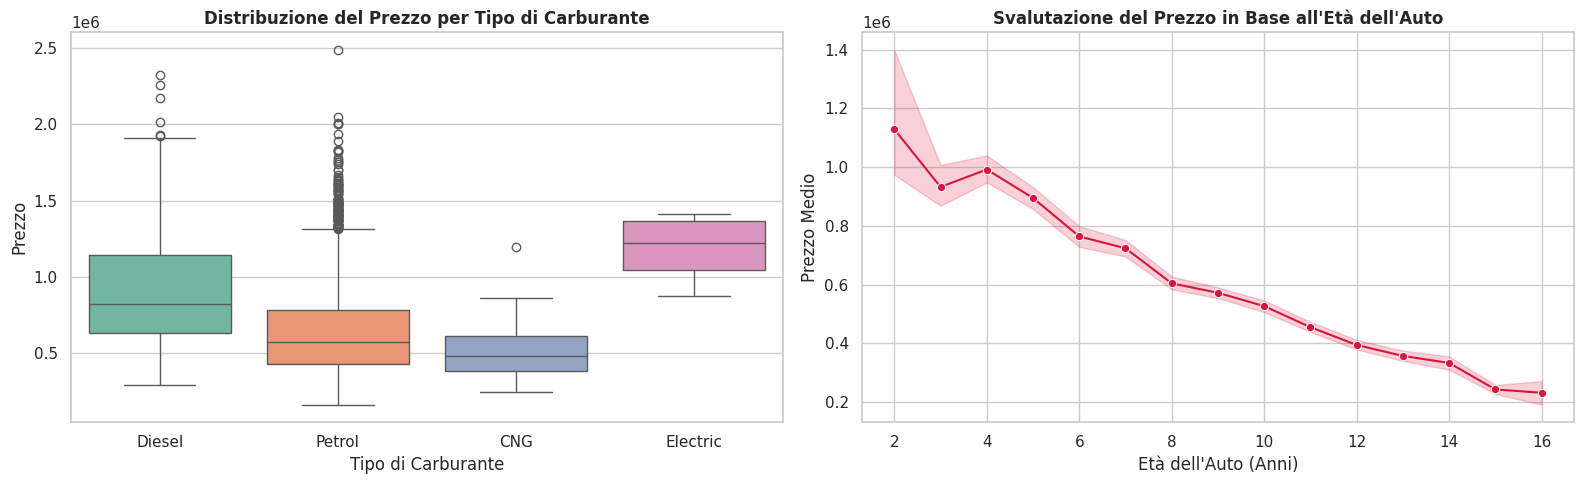

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile visivo dei grafici
sns.set_theme(style="whitegrid")

# Creiamo una figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Grafico a Scatola (Box Plot): Prezzo per Tipo di Carburante
sns.boxplot(data=df_clean, x='fuel_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Distribuzione del Prezzo per Tipo di Carburante', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo di Carburante')
axes[0].set_ylabel('Prezzo')

# 2. Grafico a Linea: Svalutazione in base all'Età dell'Auto
sns.lineplot(data=df_clean, x='car_age', y='price', ax=axes[1], marker='o', color='crimson')
axes[1].set_title('Svalutazione del Prezzo in Base all\'Età dell\'Auto', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Età dell\'Auto (Anni)')
axes[1].set_ylabel('Prezzo Medio')

# Regoliamo lo spazio tra i grafici e salviamo l'immagine per il portfolio su GitHub
plt.tight_layout()
plt.savefig('grafici_auto.png', dpi=300)
plt.show()